# Bank Customer Churn Prediction & Retention Analytics System

## 03 — Feature Engineering & ML Preparation

### Objective

This notebook prepares the cleaned banking customer dataset for machine learning.

The workflow includes:

- Loading and validating the analytical dataset
- Separating identifiers, predictors, and target
- Creating business-driven features
- Investigating feature distributions and skewness
- Preparing numerical and categorical preprocessing
- Performing a stratified train-test split
- Building a reusable preprocessing pipeline
- Preparing the dataset for churn prediction models

### Modeling Objective

The target variable is `Exited`, where:

- `0` = Customer stayed
- `1` = Customer exited

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Processed data:", DATA_PROCESSED)

Project root: C:\Users\balle\customer-churn-prediction-retention-analytics
Processed data: C:\Users\balle\customer-churn-prediction-retention-analytics\data\processed


In [3]:
file_path = DATA_PROCESSED / "bank_customer_churn_cleaned.csv"

df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")

Dataset shape: (10000, 12)


In [4]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate CustomerIds:", df["CustomerId"].duplicated().sum())

Shape: (10000, 12)
Missing values: 0
Duplicate rows: 0
Duplicate CustomerIds: 0


In [5]:
identifier = ["CustomerId"]

In [6]:
target = "Exited"

In [7]:
X = df.drop(columns=identifier + [target])
y = df[target]

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10)
y shape: (10000,)


In [11]:
y.value_counts(normalize=True).round(4) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

### Target Distribution

The target variable is moderately imbalanced, with approximately 79.63% retained customers and 20.37% churned customers.

Because the minority class represents more than one-fifth of the dataset, the imbalance is manageable but should still be considered when selecting evaluation metrics. Accuracy alone will not be sufficient for evaluating the churn prediction models.

In [12]:
X.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object

In [13]:
numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary"
]

In [14]:
categorical_features = [
    "Geography",
    "Gender",
    "NumOfProducts"
]

In [15]:
binary_features = [
    "HasCrCard",
    "IsActiveMember"
]

In [16]:
print("Numerical:", numeric_features)
print("Categorical:", categorical_features)
print("Binary:", binary_features)

Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
Categorical: ['Geography', 'Gender', 'NumOfProducts']
Binary: ['HasCrCard', 'IsActiveMember']


In [17]:
df_model = df.copy()

In [18]:
age_bins = [17, 25, 35, 45, 55, 65, 100]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df_model["AgeGroup"] = pd.cut(
    df_model["Age"],
    bins=age_bins,
    labels=age_labels
)

In [19]:
df_model["AgeGroup"].value_counts().sort_index()

AgeGroup
18-25     611
26-35    3542
36-45    3736
46-55    1311
56-65     536
66+       264
Name: count, dtype: int64

In [20]:
df_model["BalanceStatus"] = np.where(
    df_model["Balance"] == 0,
    "Zero Balance",
    "Positive Balance"
)

In [21]:
df_model["BalanceStatus"].value_counts()

BalanceStatus
Positive Balance    6383
Zero Balance        3617
Name: count, dtype: int64

In [22]:
df_model["ActivityStatus"] = df_model["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

In [23]:
df_model["ActivityStatus"].value_counts()

ActivityStatus
Active      5151
Inactive    4849
Name: count, dtype: int64

In [24]:
df_model["AgeActivity"] = (
    df_model["AgeGroup"].astype(str)
    + "_"
    + df_model["ActivityStatus"]
)

In [25]:
df_model["AgeActivity"].value_counts().head(15)

AgeActivity
36-45_Inactive    1945
26-35_Active      1802
36-45_Active      1791
26-35_Inactive    1740
46-55_Inactive     665
46-55_Active       646
56-65_Active       357
18-25_Active       323
18-25_Inactive     288
66+_Active         232
56-65_Inactive     179
66+_Inactive        32
Name: count, dtype: int64

In [26]:
df_model[
    [
        "Age",
        "AgeGroup",
        "Balance",
        "BalanceStatus",
        "IsActiveMember",
        "ActivityStatus",
        "AgeActivity"
    ]
].head(10)

,Age,AgeGroup,Balance,BalanceStatus,IsActiveMember,ActivityStatus,AgeActivity
0,42,36-45,0.00,Zero Balance,1,Active,36-45_Active
1,41,36-45,83807.86,Positive Balance,1,Active,36-45_Active
2,42,36-45,159660.80,Positive Balance,0,Inactive,36-45_Inactive
3,39,36-45,0.00,Zero Balance,0,Inactive,36-45_Inactive
4,43,36-45,125510.82,Positive Balance,1,Active,36-45_Active
5,44,36-45,113755.78,Positive Balance,0,Inactive,36-45_Inactive
6,50,46-55,0.00,Zero Balance,1,Active,46-55_Active
7,29,26-35,115046.74,Positive Balance,0,Inactive,26-35_Inactive
8,44,36-45,142051.07,Positive Balance,1,Active,36-45_Active
9,27,26-35,134603.88,Positive Balance,1,Active,26-35_Active


In [27]:
model_df = df_model.drop(
    columns=["CustomerId"]
)

In [28]:
model_df.shape

(10000, 15)

In [29]:
skewness = (
    model_df[numeric_features]
    .skew()
    .sort_values(ascending=False)
)

skewness

Age                1.011320
Tenure             0.010991
EstimatedSalary    0.002085
CreditScore       -0.071607
Balance           -0.141109
dtype: float64

In [30]:
pd.DataFrame({
    "skewness": skewness,
    "absolute_skewness": skewness.abs()
})

,skewness,absolute_skewness
Age,1.011320,1.011320
Tenure,0.010991,0.010991
EstimatedSalary,0.002085,0.002085
CreditScore,-0.071607,0.071607
Balance,-0.141109,0.141109


## Skewness Analysis

Skewness was evaluated for the main numerical predictors.

Age shows moderate positive skewness (approximately 1.01), reflecting the concentration of customers in younger and middle-age groups with fewer older customers.

Tenure, EstimatedSalary, CreditScore, and Balance have relatively low absolute skewness values and do not require transformation.

No logarithmic or other distributional transformation is applied at this stage. Numerical variables will instead be standardized where required through the machine learning preprocessing pipeline.

This approach avoids unnecessary transformations while preserving the original business interpretation of the variables.

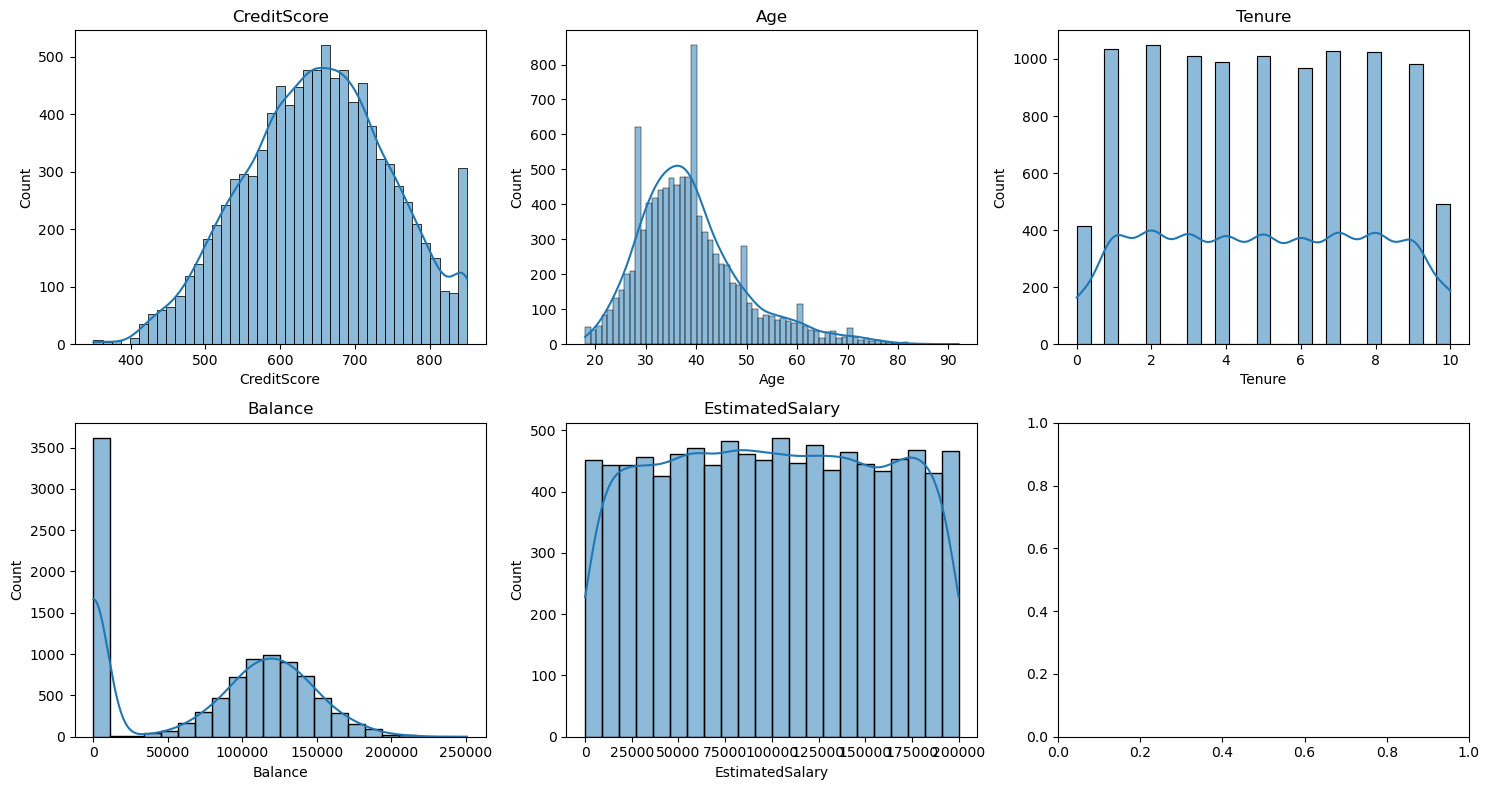

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_features):
    sns.histplot(
        model_df[col],
        kde=True,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [32]:
agegroup_churn = (
    model_df.groupby("AgeGroup", observed=True)["Exited"]
    .mean()
    .mul(100)
    .round(2)
)

agegroup_churn

AgeGroup
18-25     7.53
26-35     8.50
36-45    19.62
46-55    50.57
56-65    48.32
66+      13.26
Name: Exited, dtype: float64

In [33]:
balance_status_churn = (
    model_df.groupby("BalanceStatus")["Exited"]
    .mean()
    .mul(100)
    .round(2)
)

balance_status_churn

BalanceStatus
Positive Balance    24.08
Zero Balance        13.82
Name: Exited, dtype: float64

In [34]:
age_activity_churn = (
    model_df.groupby("AgeActivity")["Exited"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

age_activity_churn

AgeActivity
56-65_Inactive    93.85
46-55_Inactive    63.61
66+_Inactive      62.50
46-55_Active      37.15
56-65_Active      25.49
36-45_Inactive    24.22
36-45_Active      14.63
18-25_Inactive    11.11
26-35_Inactive    10.80
66+_Active         6.47
26-35_Active       6.27
18-25_Active       4.33
Name: Exited, dtype: float64

In [35]:
X = model_df.drop(columns=["Exited"])
y = model_df["Exited"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [39]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Training set: (8000, 14)
Test set: (2000, 14)

Training target distribution:
Exited
0    79.62
1    20.37
Name: proportion, dtype: float64

Test target distribution:
Exited
0    79.65
1    20.35
Name: proportion, dtype: float64


In [40]:
numeric_features_model = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary"
]

In [41]:
categorical_features_model = [
    "Geography",
    "Gender",
    "NumOfProducts",
    "AgeGroup",
    "BalanceStatus",
    "ActivityStatus",
    "AgeActivity"
]

In [42]:
binary_features_model = [
    "HasCrCard",
    "IsActiveMember"
]

In [43]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [44]:
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features_model
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features_model
        )
    ],
    remainder="passthrough"
)

In [46]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [47]:
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (8000, 31)
Processed test shape: (2000, 31)


In [53]:
pd.read_csv(model_output_path).shape

(10000, 15)

In [54]:
import joblib

models_path = PROJECT_ROOT / "models"
models_path.mkdir(exist_ok=True)

joblib.dump(
    preprocessor,
    models_path / "preprocessor.joblib"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [55]:
print("Original dataset:", df.shape)
print("Modeling dataset:", model_df.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Processed training:", X_train_processed.shape)
print("Processed test:", X_test_processed.shape)

Original dataset: (10000, 12)
Modeling dataset: (10000, 15)
Training set: (8000, 14)
Test set: (2000, 14)
Processed training: (8000, 31)
Processed test: (2000, 31)


In [56]:
model_output_path = DATA_PROCESSED / "churn_modeling_dataset.csv"

model_df.to_csv(
    model_output_path,
    index=False
)

print("Saved:", model_output_path)

Saved: C:\Users\balle\customer-churn-prediction-retention-analytics\data\processed\churn_modeling_dataset.csv


# Feature Dictionary

## Target

| Feature | Type | Description | Role |
|---|---|---|---|
| Exited | Binary | Whether the customer exited | Target |

## Original Predictors

| Feature | Type | Description | Role |
|---|---|---|---|
| CreditScore | Numerical | Customer credit score | Predictor |
| Geography | Categorical | Customer geography | Predictor |
| Gender | Categorical | Customer gender | Predictor |
| Age | Numerical | Customer age | Predictor |
| Tenure | Numerical | Years with the bank | Predictor |
| Balance | Numerical | Account balance | Predictor |
| NumOfProducts | Categorical | Number of bank products | Predictor |
| HasCrCard | Binary | Whether customer has a credit card | Predictor |
| IsActiveMember | Binary | Whether customer is active | Predictor |
| EstimatedSalary | Numerical | Estimated annual salary | Predictor |

## Engineered Features

| Feature | Type | Description | Role |
|---|---|---|---|
| AgeGroup | Categorical | Business-defined age segment | Predictor |
| BalanceStatus | Categorical | Zero vs positive balance | Predictor |
| ActivityStatus | Categorical | Active vs inactive customer | Predictor |
| AgeActivity | Categorical | Age group combined with activity status | Predictor |

## Identifier

| Feature | Type | Description | Role |
|---|---|---|---|
| CustomerId | Identifier | Unique customer identifier | Excluded from model |